In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

Done


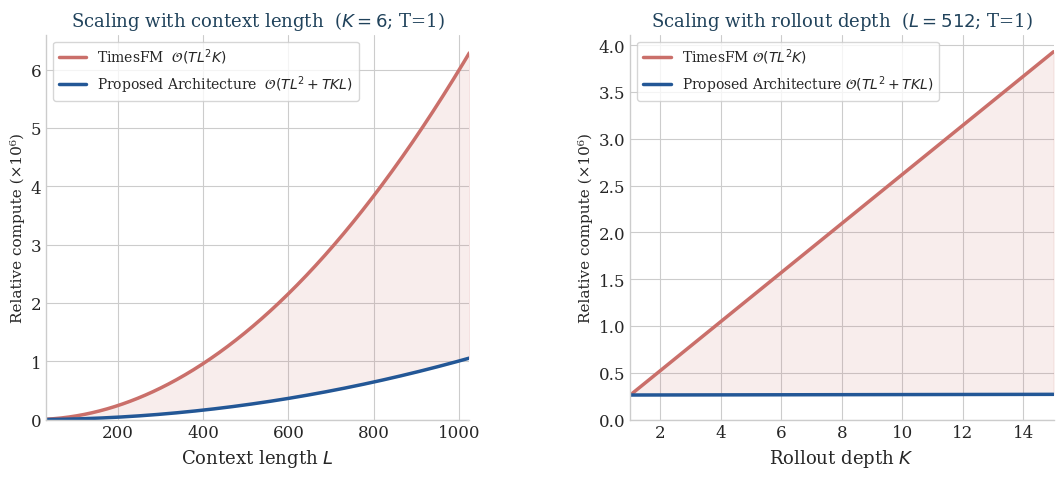

In [3]:
plt.style.use('seaborn-whitegrid')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12

C = {
    "navy":  "#235796",
    "terra": "#CA6F6A",
    "slate": "#9C9DB2",
    "sage":  "#C0D6CA",
    "midnight": "#20425B",
}

fig = plt.figure(figsize=(13, 5), facecolor="white")
gs = gridspec.GridSpec(1, 2, wspace=0.38)

# ── Left: compute vs L (fix K=6) ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
L = np.linspace(32, 1024, 500)
K_fixed = 6
T = 1  # normalise out T

window  = T * L**2 * K_fixed
forking = T * L**2 + T * K_fixed * L

ax1.plot(L, window/1e6,  color=C["terra"], lw=2.5, label="TimesFM  $\mathcal{O}(TL^2K)$")
ax1.plot(L, forking/1e6, color=C["navy"],  lw=2.5, label="Proposed Architecture  $\mathcal{O}(TL^2 + TKL)$")

# shade gap
ax1.fill_between(L, forking/1e6, window/1e6, alpha=0.12, color=C["terra"])


ax1.set_xlabel("Context length $L$", fontsize=13)
ax1.set_ylabel("Relative compute (×10⁶)", fontsize=11)
ax1.set_title(f"Scaling with context length  ($K={K_fixed}$; T=1)", fontsize=13, color=C["midnight"])
ax1.legend(fontsize=10, frameon=True)
ax1.set_xlim(32, 1024)
ax1.set_ylim(bottom=0)

# ── Right: compute vs K (fix L=512) ───────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
K = np.arange(1, 16)
L_fixed = 512

window2  = T * L_fixed**2 * K
forking2 = T * L_fixed**2 + T * K * L_fixed

ax2.plot(K, window2/1e6,  color=C["terra"], lw=2.5, label="TimesFM $\mathcal{O}(TL^2K)$")
ax2.plot(K, forking2/1e6, color=C["navy"],  lw=2.5, label="Proposed Architecture $\mathcal{O}(TL^2 + TKL)$")
ax2.fill_between(K, forking2/1e6, window2/1e6, alpha=0.12, color=C["terra"])

# annotate speedup at K=6
idx = 5  # K=6
speedup = window2[idx] / forking2[idx]

ax2.set_xlabel("Rollout depth $K$", fontsize=13)
ax2.set_ylabel("Relative compute (×10⁶)", fontsize=11)
ax2.set_title(f"Scaling with rollout depth  ($L={L_fixed}$; T=1)", fontsize=13, color=C["midnight"])
ax2.legend(fontsize=10, frameon=True)
ax2.set_xlim(1, 15)
ax2.set_ylim(bottom=0)

# fix ylim after annotations
for ax in [ax1, ax2]:
    ax.set_facecolor("white")
    for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.savefig("./complexity_tradeoff.pdf",
            dpi=200, bbox_inches="tight", facecolor="white")
print("Done")

Done


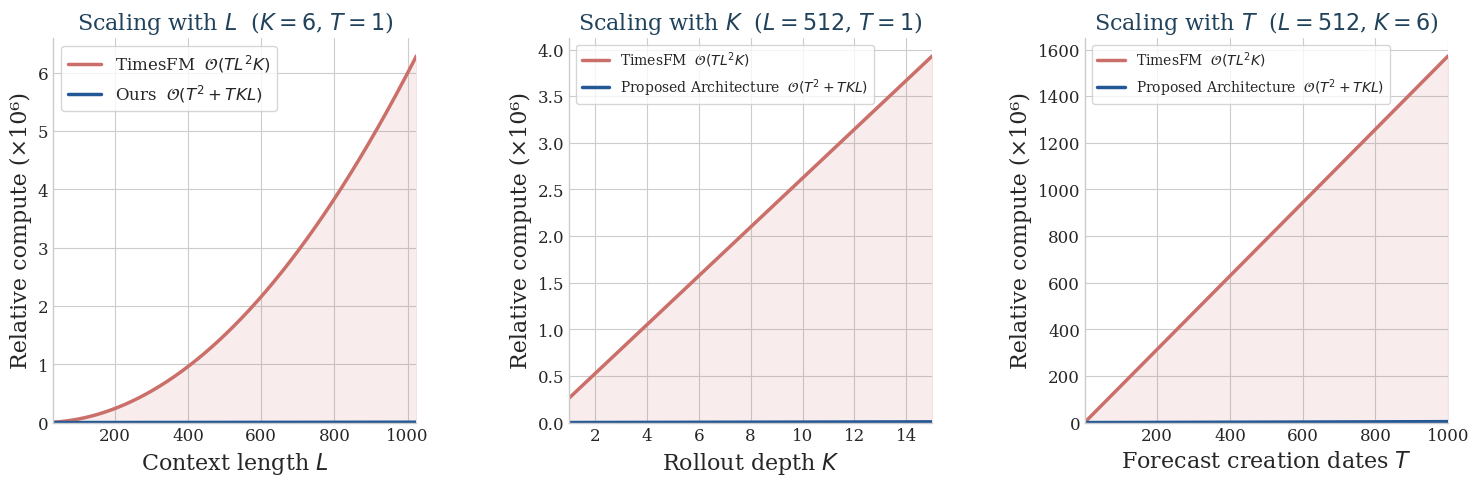

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.style.use('seaborn-whitegrid')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
fontsize = 16

C = {
    "navy":     "#235796",
    "terra":    "#CA6F6A",
    "slate":    "#9C9DB2",
    "sage":     "#C0D6CA",
    "midnight": "#20425B",
}

fig = plt.figure(figsize=(18, 5), facecolor="white")
gs = gridspec.GridSpec(1, 3, wspace=0.42)

# ── Left: compute vs L (fix K=6, T=1) ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
L = np.linspace(32, 1024, 500)
K_fixed, T_fixed = 6, 1

window  = T_fixed * L**2 * K_fixed
forking = T_fixed**2 + T_fixed * K_fixed * L   # O(T² + TKL), T=1

ax1.plot(L, window/1e6,  color=C["terra"], lw=2.5, label=r"TimesFM  $\mathcal{O}(TL^2K)$")
ax1.plot(L, forking/1e6, color=C["navy"],  lw=2.5, label=r"Ours  $\mathcal{O}(T^2 + TKL)$")
ax1.fill_between(L, forking/1e6, window/1e6, alpha=0.12, color=C["terra"])
ax1.set_xlabel("Context length $L$", fontsize=fontsize)
ax1.set_ylabel("Relative compute (×10⁶)", fontsize=fontsize)
ax1.set_title(f"Scaling with $L$  ($K={K_fixed}$, $T=1$)", fontsize=fontsize, color=C["midnight"])
ax1.legend(fontsize=fontsize-4, frameon=True)
ax1.set_xlim(32, 1024)
ax1.set_ylim(bottom=0)

# ── Middle: compute vs K (fix L=512, T=1) ─────────────────────────────────
ax2 = fig.add_subplot(gs[1])
K = np.arange(1, 16)
L_fixed = 512

window2  = T_fixed * L_fixed**2 * K
forking2 = T_fixed**2 + T_fixed * K * L_fixed

ax2.plot(K, window2/1e6,  color=C["terra"], lw=2.5, label=r"TimesFM  $\mathcal{O}(TL^2K)$")
ax2.plot(K, forking2/1e6, color=C["navy"],  lw=2.5, label=r"Proposed Architecture  $\mathcal{O}(T^2 + TKL)$")
ax2.fill_between(K, forking2/1e6, window2/1e6, alpha=0.12, color=C["terra"])

idx = 5  # K=6
speedup = window2[idx] / forking2[idx]

ax2.set_xlabel("Rollout depth $K$", fontsize=fontsize)
ax2.set_ylabel("Relative compute (×10⁶)", fontsize=fontsize)
ax2.set_title(f"Scaling with $K$  ($L={L_fixed}$, $T=1$)", fontsize=fontsize, color=C["midnight"])
ax2.legend(fontsize=10, frameon=True)
ax2.set_xlim(1, 15)
ax2.set_ylim(bottom=0)

# ── Right: compute vs T (fix L=512, K=6) ──────────────────────────────────
ax3 = fig.add_subplot(gs[2])
T = np.linspace(1, 1000, 1000)

window3  = T * L_fixed**2 * K_fixed          # O(TL²K) — linear in T
forking3 = T**2 + T * K_fixed * L_fixed      # O(T² + TKL) — quadratic in T

ax3.plot(T, window3/1e6,  color=C["terra"], lw=2.5, label=r"TimesFM  $\mathcal{O}(TL^2K)$")
ax3.plot(T, forking3/1e6, color=C["navy"],  lw=2.5, label=r"Proposed Architecture  $\mathcal{O}(T^2 + TKL)$")
ax3.fill_between(T, forking3/1e6, window3/1e6,
                 where=forking3 > window3, alpha=0.12, color=C["navy"])
ax3.fill_between(T, forking3/1e6, window3/1e6,
                 where=forking3 <= window3, alpha=0.12, color=C["terra"])

# crossover point: T² + TKL = TL²K  →  T = L²K - KL = K(L²-L) ≈ KL²
crossover = K_fixed * (L_fixed**2 - L_fixed)   # large — won't show in range
# simpler: T² = TL²K - TKL = TK(L²-L), T = K(L²-L)
# actually crossover: T + KL = L²K → T = K(L²-L) = 6*(512²-512) ≈ 1.57M, far out of range
# so in T=[1,500], ours is always more expensive — add crossover note
crossover_T = K_fixed * (L_fixed**2 - L_fixed)


ax3.set_xlabel("Forecast creation dates $T$", fontsize=fontsize)
ax3.set_ylabel("Relative compute (×10⁶)", fontsize=fontsize)
ax3.set_title(f"Scaling with $T$  ($L={L_fixed}$, $K={K_fixed}$)", fontsize=fontsize, color=C["midnight"])
ax3.legend(fontsize=10, frameon=True)
ax3.set_xlim(1, 1000)
ax3.set_ylim(bottom=0)

for ax in [ax1, ax2, ax3]:
    ax.set_facecolor("white")
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)


plt.savefig("./complexity_tradeoff.pdf",
            dpi=200, bbox_inches="tight", facecolor="white")

print("Done")